In [1]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt

In [5]:
tab = Table.read('table_dp2.Object-data-1.csv')
tab.columns

<TableColumns names=('objectId','tract','patch','coord_ra','coord_dec','refBand','refExtendedness','refSizeExtendedness','u_psfMag','u_psfMagErr','u_cModelMag','u_cModelMagErr','g_psfMag','g_psfMagErr','g_cModelMag','g_cModelMagErr','r_psfMag','r_psfMagErr','r_cModelMag','r_cModelMagErr','i_psfMag','i_psfMagErr','i_cModelMag','i_cModelMagErr','z_psfMag','z_psfMagErr','z_cModelMag','z_cModelMagErr','y_psfMag','y_psfMagErr','y_cModelMag','y_cModelMagErr','parentObjectId','shape_xx','shape_yy','shape_xy','detect_isIsolated','detect_fromBlend','deblend_parentNChild')>

(array([ 69279.,      0.,      0.,      0.,      0.,      0.,      0.,
             0.,      0., 186544.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

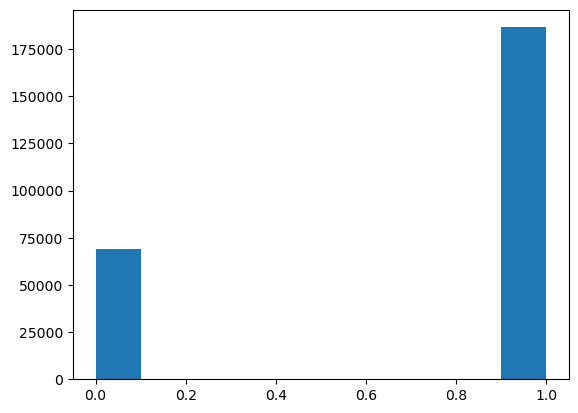

In [6]:
# refExtendedness,
plt.hist(tab['refExtendedness'])

In [16]:
gals = tab[tab['refExtendedness']==1]
stars = tab[tab['refExtendedness']==0]
print(len(gals), len(stars))

gals_clean = gals[(gals['detect_isIsolated']==True) | (gals['detect_fromBlend']==True)]
stars_clean = stars[(stars['detect_isIsolated']==True) | (stars['detect_fromBlend']==True)]
print(len(gals_clean), len(stars_clean))

186544 46754
39 39


In [19]:
plt.hist?

Signature:
plt.hist(
    x,
    bins=None,
    range=None,
    density=False,
    weights=None,
    cumulative=False,
    bottom=None,
    histtype='bar',
    align='mid',
    orientation='vertical',
    rwidth=None,
    log=False,
    color=None,
    label=None,
    stacked=False,
    *,
    data=None,
    **kwargs,
)
Docstring:
Compute and plot a histogram.

This method uses `numpy.histogram` to bin the data in *x* and count the
number of values in each bin, then draws the distribution either as a
`.BarContainer` or `.Polygon`. The *bins*, *range*, *density*, and
*weights* parameters are forwarded to `numpy.histogram`.

If the data has already been binned and counted, use `~.bar` or
`~.stairs` to plot the distribution::

    counts, bins = np.histogram(x)
    plt.stairs(counts, bins)

Alternatively, plot pre-computed bins and counts using ``hist()`` by
treating each bin as a single point with a weight equal to its count::

    plt.hist(bins[:-1], bins, weights=counts)

The data input

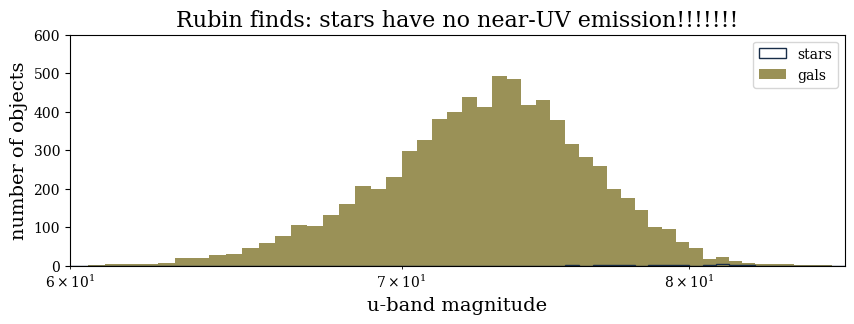

In [97]:
gals_c, stars_c = '#9a9157', '#182d48'
myfont = 'serif'
plt.figure(figsize=(10,3))
plt.hist(stars['u_psfMag'], histtype='step', bins=np.arange(10, 100, 0.5), label='stars', color=stars_c)
plt.hist(gals['u_cModelMag'], bins=np.arange(10, 100, 0.5), label='gals', color=gals_c)
plt.xlim(60,86)
plt.ylim(0,600)
# plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.rcParams['font.family'] = myfont

plt.title('Rubin finds: stars have no near-UV emission!!!!!!!', fontfamily=myfont, fontsize=16)
plt.xlabel('u-band magnitude', fontfamily=myfont, fontsize=14)
plt.ylabel('number of objects', fontfamily=myfont, fontsize=14)
plt.savefig('misleading.png', dpi=300, bbox_inches='tight')

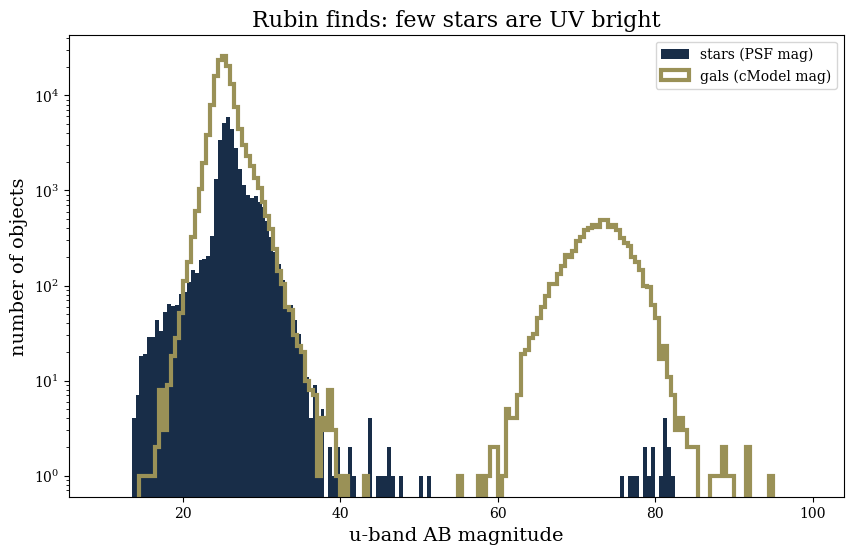

In [98]:
plt.figure(figsize=(10,6))
plt.hist(stars['u_psfMag'], bins=np.arange(10, 100, 0.5), label='stars (PSF mag)', color=stars_c)
plt.hist(gals['u_cModelMag'], histtype='step', lw=3, bins=np.arange(10, 100, 0.5), label='gals (cModel mag)', color=gals_c)
#plt.hist(gals['u_psfMag'], histtype='step', bins=np.arange(10, 100, 0.5), label='gals (PSF mag)')
#plt.xlim(60,86)
#plt.ylim(0,3000)
plt.yscale('log')
#plt.xscale('log')
plt.legend()
plt.xlabel('u-band AB magnitude', fontfamily=myfont, fontsize=14)
plt.ylabel('number of objects', fontfamily=myfont, fontsize=14)

plt.title('Rubin finds: few stars are UV bright', fontfamily=myfont, fontsize=16)
plt.savefig('truthish.png', dpi=300, bbox_inches='tight')

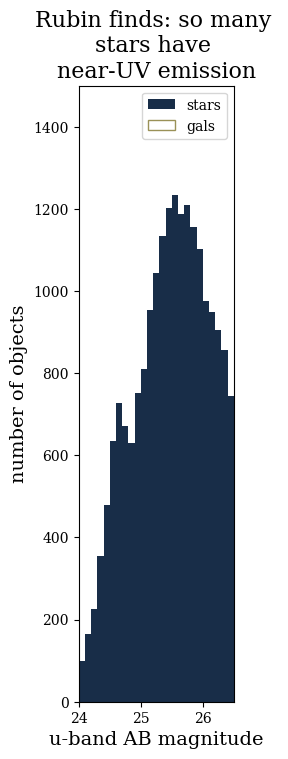

In [99]:
plt.figure(figsize=(2,8))
plt.hist(stars['u_psfMag'], bins=np.arange(10, 100, 0.1), label='stars', color=stars_c)
plt.hist(gals['u_cModelMag'], histtype='step', bins=np.arange(10, 100, 0.5), label='gals', color=gals_c)
#plt.hist(gals['u_psfMag'], histtype='step', bins=np.arange(10, 100, 0.5), label='gals (PSF mag)')
plt.xlim(24,26.5)
plt.ylim(0,1500)
#plt.yscale('log')
#plt.xscale('log')
plt.legend()
plt.xlabel('u-band AB magnitude', fontfamily=myfont, fontsize=14)
plt.ylabel('number of objects', fontfamily=myfont, fontsize=14)

plt.title('Rubin finds: so many \nstars have \nnear-UV emission', fontfamily=myfont, fontsize=16)
plt.savefig('misleading_reverse.png', dpi=300, bbox_inches='tight')

In [10]:
np.unique(tab['detect_isIsolated'])

false
true
